# Local distillation on bcTCGA

`y` = BRCA1 expression, `X` = the other 17,322 genes (n = 536).

Can we predict BRCA1 expression from the other genes?
Hopefully so; there should be correlation across genes. This is an example in High-Dimensional
Regression Modeling by Breheny and Huang:  https://pbreheny.org/7240/s25/book.pdf. 

In [ ]:
# ---- setup ------------------------------------------------------------
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import sys, time, urllib.request, ssl
from pathlib import Path
import numpy as np
import adelie as ad
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import AgglomerativeClustering
from tabpfn import TabPFNRegressor

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else (
        "mps" if torch.backends.mps.is_available() else "cpu")
except ImportError:
    DEVICE = "cpu"

REPO = Path("local-distillation-benchmark")
sys.path.insert(0, str(REPO / "benchmark_methods"))
from common import (adelie_lasso_cv, adelie_lasso_predict, local_distill,
                    teacher_similarity, tabpfn_predict)

# ---- experiment configuration (everything tunable lives here) ---------
SEED      = 0        # fixed seed for the main split
TEST_SIZE = 0.40     # 60/40 -> 322 train / 214 test
SIS_KEEP  = 500      # teacher-only marginal screen
B_DRAWS   = 100       # randomized refits per test point
# the randomization scale t is selected in Section 2 below
N_SPLITS  = 100       # replicate splits in Section 2
ALPHA = 1

print(f"device={DEVICE}")

device=mps


In [2]:
# ---- data -------------------------------------------------------------
BRCA1_RDS = "brca1.rds"
if not os.path.exists(BRCA1_RDS):
    url = "https://github.com/IowaBiostat/data-sets/raw/main/brca1/brca1.rds"
    req = urllib.request.Request(url, headers={"User-Agent": "x"})
    with urllib.request.urlopen(req, context=ssl._create_unverified_context()) as r:
        open(BRCA1_RDS, "wb").write(r.read())        # ~36 MB


def load_brca1():
    import rdata
    parsed = rdata.parser.parse_file(BRCA1_RDS)
    cmap = dict(rdata.conversion.DEFAULT_CLASS_MAP)
    cmap["data.frame"] = lambda obj, attrs: obj
    d = rdata.conversion.convert(parsed, constructor_dict=cmap)
    X = d["X"]
    genes = np.array([str(g) for g in X.coords["dim_1"].values])
    return np.asarray(X, float), np.asarray(d["y"], float).ravel(), genes


Xb, yb, genes = load_brca1()
print(f"bcTCGA/brca1: n={Xb.shape[0]}, p={Xb.shape[1]}")

# symbols from the original TCGA data that HGNC has since renamed
RENAME = {"WDR51A": "POC1A", "C15orf37": "ST20-AS1", "FLJ10241": "DMAC2",
          "C17orf61": "TMEM256", "C3orf10": "BRK1", "C2orf43": "LDAH",
          "KIAA0101": "PCLAF", "DKFZP686E2158": "SMIM15"}
disp = np.array([RENAME.get(g, g) for g in genes])

bcTCGA/brca1: n=536, p=17322


In [3]:
# ---- teacher and randomized local fit ---------------------------------
def _marginal_r(Xtr, ytr):
    return np.abs((Xtr - Xtr.mean(0)).T @ (ytr - ytr.mean())) / (
        Xtr.std(0) * ytr.std() * len(ytr) + 1e-12)


def tabpfn_screened_predict(Xtr, ytr, Xte, keep=SIS_KEEP, seed=SEED):
    """TabPFN teacher on the top-`keep` genes by marginal correlation.

    The screen uses y, so it is refit on whatever rows it is handed -- never
    on test rows.  Only the TEACHER is screened; the student and the local
    models see all p genes."""
    cols = np.argsort(-_marginal_r(Xtr, ytr))[:keep]
    m = TabPFNRegressor(device=DEVICE, random_state=seed).fit(Xtr[:, cols], ytr)
    return m.predict(Xte[:, cols])


def local_fit(Xin, yin, xq, tq, S, mu, lam, tau, rng, alpha=ALPHA, n_draws=0):
    """Augmented weighted elastic net at one query point, whitened form.

    Omega = diag(S_1..S_n, mu/sqrt(n_eff)); randomization is iid N(0, tau^2)
    added to Z = Omega^{1/2} Ybar.  Agrees with local_distill at tau=0 to
    ~2e-3 (single-lambda cold-start tolerance).  n_draws=0 -> unperturbed."""
    n_eff = 1.0 / np.sum(S ** 2)
    w = np.concatenate([S, [mu / np.sqrt(n_eff)]])
    s = np.sqrt(w)
    Xa = np.vstack([Xin, xq[None, :]])
    V = np.asfortranarray(np.hstack([s[:, None], s[:, None] * Xa]))
    Z = s * np.concatenate([yin, [tq]])
    pen = np.ones(V.shape[1]); pen[0] = 0.0          # intercept unpenalized

    def fit(Zv):
        st = ad.solver.grpnet(
            V, ad.glm.gaussian(Zv.astype(np.float64)), alpha=alpha,
            lmda_path=np.array([lam / len(Zv)]), intercept=False,
            penalty=pen, progress_bar=False)
        return st.betas[0].toarray().ravel()[1:]

    if n_draws == 0:
        return fit(Z)
    return np.array([fit(Z + rng.normal(0.0, tau, size=len(Z)))
                     for _ in range(n_draws)])

## 1. Fixed split: nuisances, $\hat\mu$, $\lambda$, predictions

In [4]:
# ---- one split: nuisances, mu-hat, lambda, predictions ----------------
t0 = time.perf_counter()

X_tr, X_te, y_tr, y_te = train_test_split(
    Xb, yb, test_size=TEST_SIZE, random_state=SEED)
sc = StandardScaler().fit(X_tr)
X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)

kf = list(KFold(5, shuffle=True, random_state=SEED).split(X_tr))
t_oof = np.zeros(len(y_tr))
s_oof = np.zeros(len(y_tr))
for a, b in kf:
    t_oof[b] = tabpfn_screened_predict(X_tr[a], y_tr[a], X_tr[b])
    f = adelie_lasso_cv(X_tr[a], y_tr[a], n_folds=5, seed=SEED, alpha = ALPHA)
    s_oof[b] = adelie_lasso_predict(X_tr[b], f["beta"], f["intercept"])

t_te = tabpfn_screened_predict(X_tr, y_tr, X_te)
gcv  = adelie_lasso_cv(X_tr, y_tr, n_folds=5, seed=SEED, alpha = ALPHA)
lam  = float(gcv["best_lambda"])
gbeta = gcv["beta"]
g_te = adelie_lasso_predict(X_te, gbeta, gcv["intercept"])

ld = local_distill(X_tr, y_tr, X_te,
                   teacher_preds_test=t_te, teacher_oof_preds=t_oof,
                   student_oof_preds=s_oof, lambda_=lam,
                   random_state=SEED, lambda_scale="fixed", alpha=ALPHA)

print(f"n_train={len(y_tr)}  n_test={len(y_te)}  "
      f"mu-hat={ld['mu']:.3f}  lambda={lam:.5f}  "
      f"({time.perf_counter()-t0:.0f}s)\n")

print(f"{'method':22s}{'test MSE':>10s}{'test R2':>10s}")
preds = {"global lasso (student)": g_te,
         "TabPFN (teacher)":       t_te,
         "local distillation":     ld["predictions"]}
for k, v in preds.items():
    print(f"{k:22s}{mean_squared_error(y_te, v):10.4f}{r2_score(y_te, v):10.3f}")

print(f"\nactive genes: global={int((np.abs(gbeta) > 1e-8).sum())}  "
      f"local median={np.median((np.abs(ld['betas']) > 1e-8).sum(1)):.0f}")
print(f"n_eff: median {np.median(ld['n_eff']):.0f} "
      f"[{ld['n_eff'].min():.0f}-{ld['n_eff'].max():.0f}]")

n_train=321  n_test=215  mu-hat=1.392  lambda=0.03880  (86s)

method                  test MSE   test R2
global lasso (student)    0.1885     0.579
TabPFN (teacher)          0.1500     0.665
local distillation        0.1482     0.669

active genes: global=123  local median=94
n_eff: median 211 [3-237]


## 2. Choosing the randomization scale $t$

In [5]:
# ---- choose t by leave-one-out on the training set ---------------------
# Each training point is a query point with its own weight zeroed, so the fit
# uses the other n-1 rows.  We take the largest t whose OOF PSE stays within
# TOL of the unperturbed value.
S    = ld["sim_weights"]
mu   = float(ld["mu"])
sig  = (y_tr - t_oof).std()
phi  = t_te

FRAC_SUB  = 0.2
GRID_CTAU = [0.01, 0.05, 0.1, 0.25, 0.5, 1]
B_SWEEP   = 100
TOL       = 0.05

rng = np.random.default_rng(SEED)
sub = np.sort(rng.choice(len(y_tr), size=int(FRAC_SUB * len(y_tr)),
                         replace=False))
var_phi = t_oof.var()


def local_fit_yhat(Xin, yin, xq, tq, S, mu, lam, tau, rng, n_draws=0):
    """Same augmented whitened fit as local_fit, but returns predictions
    (intercept + xq @ beta) instead of coefficients."""
    n_eff = 1.0 / np.sum(S ** 2)
    w = np.concatenate([S, [mu / np.sqrt(n_eff)]])
    s = np.sqrt(w)
    Xa = np.vstack([Xin, xq[None, :]])
    V = np.asfortranarray(np.hstack([s[:, None], s[:, None] * Xa]))
    Z = s * np.concatenate([yin, [tq]])
    pen = np.ones(V.shape[1]); pen[0] = 0.0

    def fit(Zv):
        st = ad.solver.grpnet(
            V, ad.glm.gaussian(Zv.astype(np.float64)), alpha=1.0,
            lmda_path=np.array([lam / len(Zv)]), intercept=False,
            penalty=pen, progress_bar=False)
        b = st.betas[0].toarray().ravel()
        return float(b[0] + xq @ b[1:])

    if n_draws == 0:
        return fit(Z)
    return np.array([fit(Z + rng.normal(0.0, tau, size=len(Z)))
                     for _ in range(n_draws)])


# per-point OOF weights (self excluded) and n_eff
S_sub = np.zeros((len(sub), len(y_tr)))
for k, j in enumerate(sub):
    d = (t_oof - t_oof[j]) ** 2 / var_phi
    d[j] = np.inf                      # exclude self
    d = d - d.min()                    # stabilize before exponentiating
    S_sub[k] = np.exp(-d)
    S_sub[k] /= S_sub[k].sum()
assert np.isfinite(S_sub).all(), "non-finite similarity weights"
n_eff_sub = 1.0 / (S_sub ** 2).sum(1)

yhat0 = np.zeros(len(sub))
yhatB = np.zeros((len(GRID_CTAU), B_SWEEP, len(sub)))

t0 = time.perf_counter()
for k, j in enumerate(sub):
    yhat0[k] = local_fit_yhat(X_tr, y_tr, X_tr[j], t_oof[j], S_sub[k],
                              mu, lam, 0.0, rng, n_draws=0)
    for c, ct in enumerate(GRID_CTAU):
        tau = np.sqrt(ct / n_eff_sub[k]) * sig
        yhatB[c, :, k] = local_fit_yhat(X_tr, y_tr, X_tr[j], t_oof[j],
                                        S_sub[k], mu, lam, tau, rng,
                                        n_draws=B_SWEEP)
    if k % 25 == 0:
        el = time.perf_counter() - t0
        print(f"  {k:4d}/{len(sub)}  {el:.0f}s  "
              f"eta {el/(k+1)*(len(sub)-k-1):.0f}s", flush=True)

np.savez_compressed("bctcga_ctau_sweep.npz", sub=sub, yhat0=yhat0,
                    yhatB=yhatB, grid=np.array(GRID_CTAU),
                    n_eff_sub=n_eff_sub)

     0/64  21s  eta 1296s
    25/64  470s  eta 687s
    50/64  902s  eta 230s


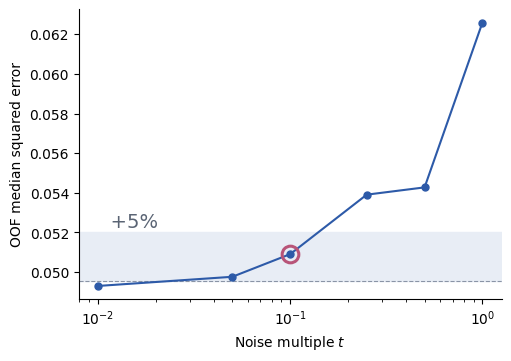

unperturbed 0.0496, +5% = 0.0520, selected t = 0.1


In [6]:
y_sub = y_tr[sub]
mse0  = np.mean((y_sub - yhat0) ** 2)
mse_m = ((y_sub[None, None, :] - yhatB) ** 2).mean((1, 2))

mse0  = np.median((y_sub - yhat0) ** 2)
mse_m = np.median(((y_sub[None, None, :] - yhatB) ** 2).mean(1), axis=1)

ok = mse_m <= mse0 * (1 + TOL)
C_STAR = max(np.array(GRID_CTAU)[ok]) if ok.any() else GRID_CTAU[0]

fig, ax = plt.subplots(figsize=(5, 3.5), layout="constrained")
ax.axhspan(mse0, mse0 * (1 + TOL), color="#e8edf5", zorder=0)
ax.axhline(mse0, color="#8a94a6", lw=0.8, ls="--", zorder=1)
ax.plot(GRID_CTAU, mse_m, "o-", color="#2d5aa8", ms=5, zorder=3)
ax.plot([C_STAR], [mse_m[GRID_CTAU.index(C_STAR)]], "o", ms=12,
        mfc="none", mec="#b85478", mew=2.2, zorder=5)
ax.text(GRID_CTAU[0], mse0 * (1 + TOL), f"  +{TOL:.0%}",
        va="bottom", ha="left", fontsize=14, color="#5a6474")
ax.set_xscale("log")
ax.set_xlabel(r"Noise multiple $t$")
ax.set_ylabel("OOF median squared error")
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("bctcga_ctau_mse.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

print(f"unperturbed {mse0:.4f}, +{TOL:.0%} = {mse0*(1+TOL):.4f}, "
      f"selected t = {C_STAR}")

## 3. Randomized refits

In [7]:
# ---- randomized refits for every test point ---------------------------
# S, mu, sig, phi and C_STAR come from the sections above
rng  = np.random.default_rng(SEED)

n_te, p = len(y_te), Xb.shape[1]
beta0 = np.zeros((n_te, p), dtype=np.float32)
betaB = np.zeros((B_DRAWS, n_te, p), dtype=np.float32)

t0 = time.perf_counter()
for i in range(n_te):
    tau = np.sqrt(C_STAR / ld["n_eff"][i]) * sig
    beta0[i]    = local_fit(X_tr, y_tr, X_te[i], t_te[i], S[i], mu, lam,
                            tau, rng, n_draws=0)
    betaB[:, i] = local_fit(X_tr, y_tr, X_te[i], t_te[i], S[i], mu, lam,
                            tau, rng, n_draws=B_DRAWS)
    if i % 25 == 0:
        el = time.perf_counter() - t0
        print(f"  {i:4d}/{n_te}  nnz={(np.abs(beta0[i]) > 1e-8).sum():4d}  "
              f"tau={tau:.5f}  {el:.0f}s  eta {el/(i+1)*(n_te-i-1):.0f}s",
              flush=True)

np.savez_compressed("bctcga_local_betas.npz",
                    beta0=beta0, betaB=betaB, phi=phi, genes=genes)

PI  = (np.abs(betaB) > 1e-8).mean(0)                 # selection prob per point
nnz = (np.abs(beta0) > 1e-8).sum(1)
stable = np.array([(PI[i][np.abs(beta0[i]) > 1e-8] > 0.9).mean()
                   for i in range(n_te)])
print(f"\nnnz median {np.median(nnz):.0f} [{nnz.min()}-{nnz.max()}]   "
      f"stable fraction (pi>0.9) {stable.mean():.2f}")

     0/215  nnz=  93  tau=0.00944  3s  eta 580s
    25/215  nnz=  88  tau=0.00973  75s  eta 544s
    50/215  nnz=  99  tau=0.01090  147s  eta 472s
    75/215  nnz=  91  tau=0.00924  216s  eta 395s
   100/215  nnz=  95  tau=0.00897  285s  eta 321s
   125/215  nnz=  90  tau=0.01133  358s  eta 253s
   150/215  nnz=  94  tau=0.01025  432s  eta 183s
   175/215  nnz=  96  tau=0.01223  505s  eta 112s
   200/215  nnz=  89  tau=0.00922  575s  eta 40s

nnz median 95 [15-110]   stable fraction (pi>0.9) 0.16


## 4. Clustering

2 0.36 [ 92 123]
3 0.377 [78 81 56]
4 0.399 [57 74 28 56]
5 0.401 [55 44 28 31 57]
6 0.392 [37 40 41 18 51 28]
7 0.397 [37 39 18 51 32 10 28]
8 0.375 [30 27 44 24 10 32 30 18]
9 0.378 [30 33 35  6 10 23 18 33 27]
10 0.365 [30 24 27 22 27 10 18  6 28 23]
11 0.372 [ 9 24 25 22 26 24  9 11  6 36 23]

selected K = 5


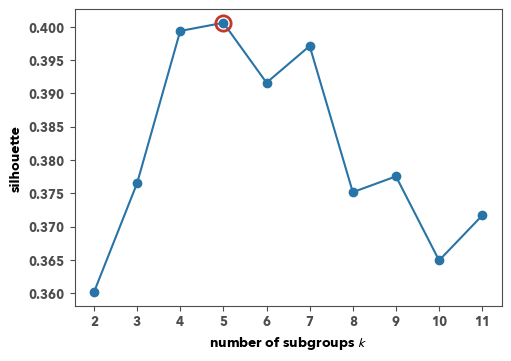

In [8]:
# ---- elbow plot -------------------------------------------------------
# ks, scores = list(range(2, 12)), []
# for k in ks:
#     l0 = AgglomerativeClustering(n_clusters=k).fit_predict(beta0)
#     scores.append(silhouette_score(beta0, l0))
#     print(k, round(scores[-1], 3), np.bincount(l0))

# K = ks[int(np.argmax(scores))]
# print(f"\nselected K = {K}")

from sklearn.cluster import KMeans

ks, scores = list(range(2, 12)), []
for k in ks:
    l0 = KMeans(k, n_init=10, random_state=SEED).fit_predict(beta0)
    scores.append(silhouette_score(beta0, l0))
    print(k, round(scores[-1], 3), np.bincount(l0))

K = ks[int(np.argmax(scores))]
print(f"\nselected K = {K}")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Avenir Next", "Avenir", "Helvetica Neue", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.edgecolor": "0.3", "axes.linewidth": 0.8,
    "xtick.color": "0.3", "ytick.color": "0.3", "figure.facecolor": "white",
})

fig, ax = plt.subplots(figsize=(5, 3.5), layout="constrained")
ax.plot(ks, scores, "o-", color="#2874a6")
ax.plot([K], [max(scores)], "o", ms=11, mfc="none", mec="#c0392b", mew=2)
ax.set_xlabel("number of subgroups $k$"); ax.set_ylabel("silhouette")
ax.set_xticks(ks)
plt.savefig("bctcga_silhouette.pdf", bbox_inches="tight")
plt.show()

subgroup sizes: [33, 40, 58, 56, 28]


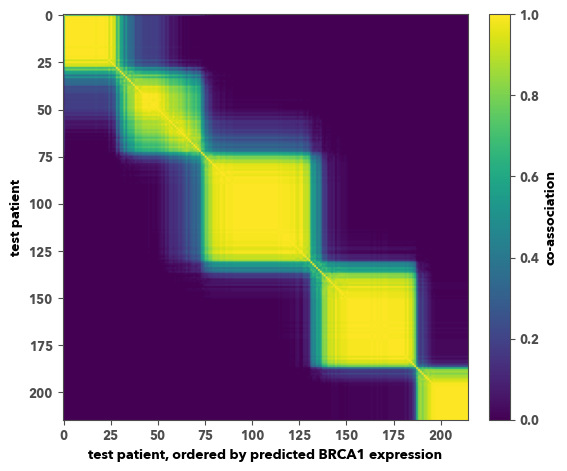

In [9]:
# ---- evidence-accumulation clustering (Sec 5.3, steps 2-3) ------------
o = np.argsort(phi)

co = np.zeros((n_te, n_te))
for b in range(B_DRAWS):
    l = KMeans(K, n_init=10, random_state=SEED + b).fit_predict(betaB[b])
    co += (l[:, None] == l[None, :])
co /= B_DRAWS
lab = AgglomerativeClustering(n_clusters=K, metric="precomputed",
                              linkage="average").fit_predict(1 - co)
rows_c = np.argsort([phi[lab == c].mean() for c in range(K)])
print("subgroup sizes:", [int(np.sum(lab == c)) for c in rows_c])

fig, ax = plt.subplots(figsize=(5.5, 4.6), layout="constrained")
im = ax.imshow(co[np.ix_(o, o)], cmap="viridis", vmin=0, vmax=1)
ax.set_xlabel("test patient, ordered by predicted BRCA1 expression")
ax.set_ylabel("test patient")
fig.colorbar(im, ax=ax, label="co-association")
plt.savefig("bctcga_coassociation.pdf", bbox_inches="tight")
plt.show()

### Figures

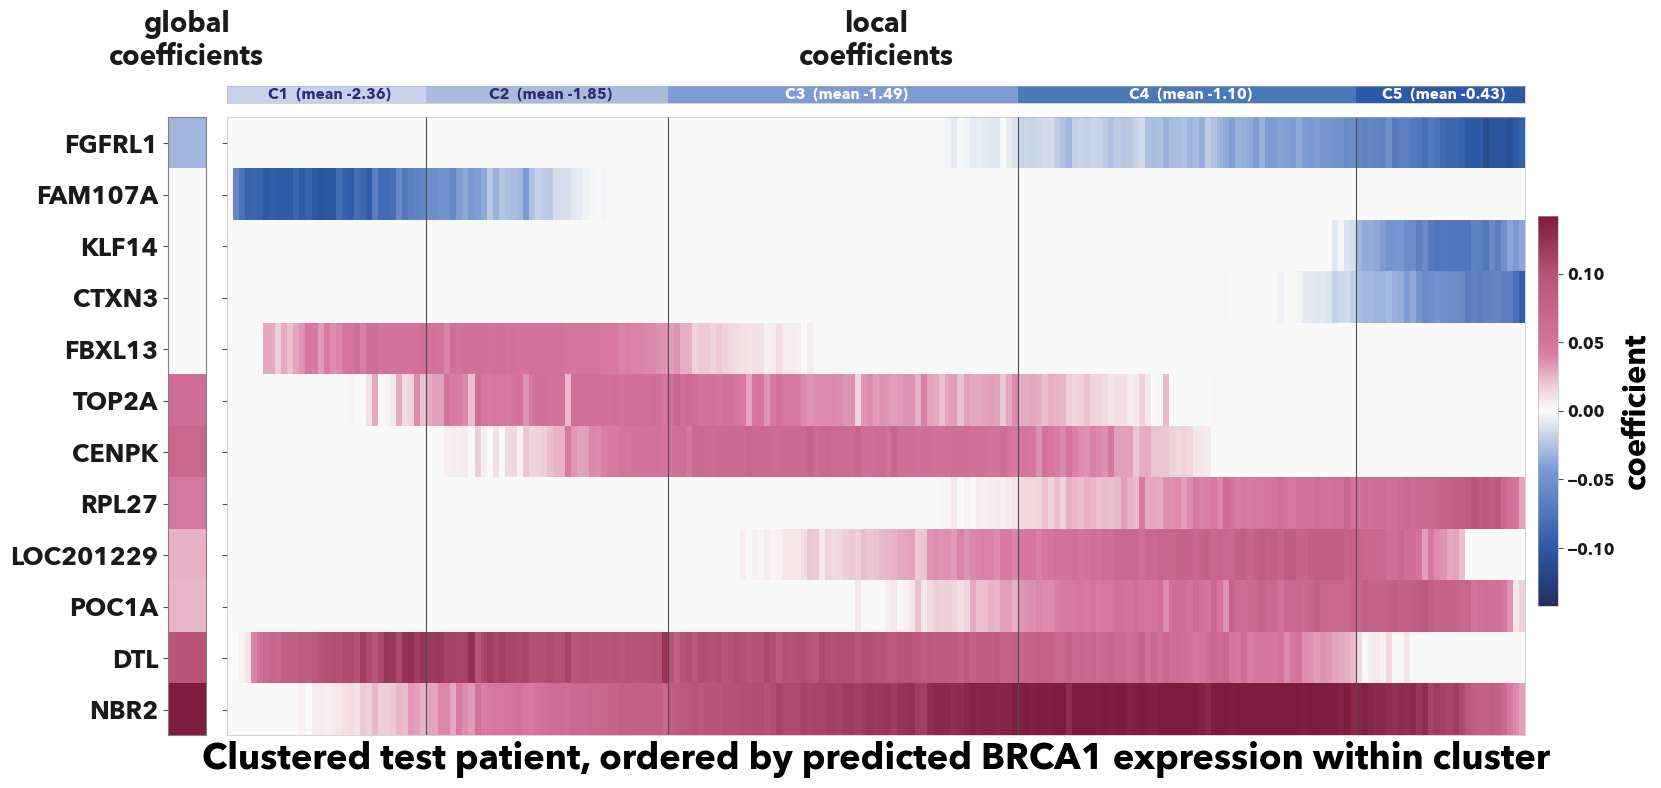

In [10]:
# ---- coefficient heatmap ----------------------------------------------
from matplotlib.colors import ListedColormap

N_GENES = 15

# --- paper style (matches visualize_results.R / visualize_ablation.R) ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Avenir Next", "Avenir", "Helvetica Neue", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "font.size": 14, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "axes.edgecolor": "#b3b3b3", "axes.linewidth": 0.4,
    "xtick.color": "#4d4d4d", "ytick.color": "#4d4d4d",
    "figure.facecolor": "white", "axes.facecolor": "white",
})

CLUSTER_COLS = ["#c5d3ec", "#a8bcdd", "#7d9bd4", "#4a78b8", "#2d5aa8"]
import matplotlib.colors as mc

LD_DIVERGING = mc.LinearSegmentedColormap.from_list("ld_div", [
    (0.00, "#22305e"),   # deep ultramarine   (near method_colors["Lasso"])
    (0.15, "#2d5aa8"),   # TabPFN blue
    (0.35, "#7d9bd4"),   # light blue
    (0.44, "#c8d5e8"),
    (0.50, "#fbfbfb"),
    (0.56, "#efd2da"),
    (0.65, "#d97aa3"),   # light rose
    (0.85, "#b85478"),   # mid wine-rose
    (1.00, "#7d1c3f"),   # deep wine
], N=256)

act = np.abs(beta0).max(0) > 1e-8
Bm, gidx = beta0[:, act], np.flatnonzero(act)
means = np.vstack([Bm[lab == c].mean(0) for c in range(K)])

score = means[rows_c].std(0)          # sd of subgroup means, not of patients
keep_g = np.union1d(np.argsort(-score)[:N_GENES - 3],
                    np.argsort(-np.abs(means).max(0))[:3])

# keep_g = np.argsort(-Bm.std(0))[:N_GENES]
order_g = keep_g[np.argsort(means[rows_c].mean(0)[keep_g])]

ord_pt = np.concatenate([np.flatnonzero(lab == c)[np.argsort(phi[lab == c])]
                         for c in rows_c])
sizes = [int(np.sum(lab == c)) for c in rows_c]
bounds = np.cumsum(sizes)[:-1]

M = Bm[np.ix_(ord_pt, order_g)].T
G = gbeta[gidx[order_g]][:, None]
v = np.quantile(np.abs(M), 0.99)
norm = TwoSlopeNorm(0, -v, v)
strip = np.concatenate([np.full(s, k) for k, s in enumerate(sizes)])[None, :]

fig, ax = plt.subplots(2, 2, figsize=(16.5, 7), sharey="row", sharex="col",
                       layout="constrained",
                       gridspec_kw={"width_ratios": [1, 34],
                                    "height_ratios": [1, 36],
                                    "wspace": 0.02, "hspace": 0.04})
ax[0, 0].axis("off")

ax[0, 1].imshow(strip, aspect="auto", interpolation="nearest",
                cmap=ListedColormap(CLUSTER_COLS[:K]), vmin=0, vmax=K - 1)
ax[0, 1].set_yticks([]); ax[0, 1].set_xticks([]); ax[0, 1].tick_params(left=False)
lo = 0
for k, s in enumerate(sizes):
    mphi = phi[ord_pt][lo:lo + s].mean()
    ax[0, 1].text(lo + s / 2, 0, f"C{k+1}  (mean {mphi:.2f})",
                  ha="center", va="center", fontsize=11, weight="bold",
                  color="white" if k >= 2 else "#2d2e6f")
    lo += s

ax[1, 0].imshow(G, cmap=LD_DIVERGING, norm=norm, aspect="auto", interpolation="nearest")
ax[1, 0].set_xticks([]); 
ax[1, 0].set_yticks(range(len(order_g)))
ax[1, 0].set_yticklabels([disp[gidx[j]] for j in order_g],
                         fontsize=18, color="#1a1a1a")
for sp in ax[1, 0].spines.values():
    sp.set_color("#808080"); sp.set_linewidth(0.8)

im = ax[1, 1].imshow(M, cmap=LD_DIVERGING, norm=norm, aspect="auto",
                     interpolation="nearest")
for b in bounds:
    ax[1, 1].axvline(b - 0.5, color="#4d4d4d", lw=0.8)
ax[1, 1].set_xticks([])
ax[1, 1].set_xlabel("Clustered test patient, ordered by predicted "
                    "BRCA1 expression within cluster", fontsize=26)
cb = fig.colorbar(im, ax=ax[:, 1], fraction=0.015, pad=0.01)
cb.set_label("coefficient", fontsize=22)
cb.ax.tick_params(labelsize=12, labelcolor="#1a1a1a")
cb.outline.set_linewidth(0.4); cb.outline.set_edgecolor("#b3b3b3")

fig.canvas.draw()
p0, p1 = ax[0, 0].get_position(), ax[0, 1].get_position()
fig.text(p0.x0 + p0.width / 2, p1.y1 + 0.02, "global\ncoefficients",
         ha="center", va="bottom", fontsize=20, color="#1a1a1a")
fig.text(p1.x0 + p1.width / 2, p1.y1 + 0.02, "local\ncoefficients",
         ha="center", va="bottom", fontsize=20, color="#1a1a1a")

plt.savefig("bctcga_local_coefs.pdf", bbox_inches="tight")
plt.show()

In [11]:
# ---- M4 check: clustering vs quantile bins of predicted expression -----
from sklearn.metrics import adjusted_rand_score

qbin = np.digitize(phi, np.quantile(phi, np.arange(1, K) / K))

print(f"ARI(clusters, quantile bins) = {adjusted_rand_score(lab, qbin):.3f}")

for rank, c in enumerate(rows_c):
    in_range = (phi >= phi[lab == c].min()) & (phi <= phi[lab == c].max())
    frac = (lab[in_range] == c).mean()
    print(f"C{rank+1}: size {np.sum(lab == c):3d}  "
          f"phi [{phi[lab == c].min():.2f}, {phi[lab == c].max():.2f}]  "
          f"contiguity {frac:.2f}")

conf = np.array([[np.sum((lab == c) & (qbin == b)) for b in range(K)]
                 for c in rows_c])
print("\ncluster x bin counts:\n", conf)

# coefficient dilution at the paper's headline genes
mc = np.array([beta0[lab == c].mean(0) for c in rows_c])
mb = np.array([beta0[qbin == b].mean(0) for b in range(K)])
for g in ["FAM107A", "KLF14"]:
    j = int(np.flatnonzero(disp == g)[0])
    print(f"\n{g}: cluster means {np.round(mc[:, j], 3)}")
    print(f"{'':{len(g)}}  bin     means {np.round(mb[:, j], 3)}")

# and the genes where the two partitions disagree most
d = np.abs(mc - mb).max(0)
for j in np.argsort(-d)[:5]:
    print(f"{disp[j]:12s} max diff {d[j]:.3f}  "
          f"cluster {np.round(mc[:, j], 3)}  bin {np.round(mb[:, j], 3)}")

ARI(clusters, quantile bins) = 0.625
C1: size  33  phi [-3.60, -2.02]  contiguity 0.97
C2: size  40  phi [-2.02, -1.68]  contiguity 0.98
C3: size  58  phi [-1.67, -1.32]  contiguity 1.00
C4: size  56  phi [-1.30, -0.83]  contiguity 1.00
C5: size  28  phi [-0.76, 0.16]  contiguity 1.00

cluster x bin counts:
 [[33  0  0  0  0]
 [10 30  0  0  0]
 [ 0 13 43  2  0]
 [ 0  0  0 41 15]
 [ 0  0  0  0 28]]

FAM107A: cluster means [-0.083 -0.02   0.     0.     0.   ]
         bin     means [-0.075 -0.008  0.     0.     0.   ]

KLF14: cluster means [ 0.     0.     0.    -0.001 -0.056]
       bin     means [ 0.     0.     0.     0.    -0.037]
KLF14        max diff 0.019  cluster [ 0.     0.     0.    -0.001 -0.056]  bin [ 0.     0.     0.     0.    -0.037]
LOC201229    max diff 0.016  cluster [0.    0.    0.018 0.069 0.034]  bin [0.    0.    0.022 0.063 0.05 ]
NBR2         max diff 0.016  cluster [0.01  0.058 0.114 0.142 0.104]  bin [0.016 0.074 0.119 0.142 0.118]
CENPK        max diff 0.016  clus

In [12]:
# ---- M6: stability of the FAM107A / KLF14 claims -----------------------
PI = (np.abs(betaB) > 1e-8).mean(0)          # (n_te, p) selection freqs
for g in ["FAM107A", "KLF14"]:
    j = int(np.flatnonzero(disp == g)[0])
    freq = [PI[lab == c, j].mean() for c in rows_c]     # mean pi per cluster
    sel0 = [(np.abs(beta0[lab == c, j]) > 1e-8).mean() for c in rows_c]
    print(f"{g}: unperturbed selection rate by cluster "
          f"{np.round(sel0, 2)}")
    print(f"{'':{len(g)}}  mean randomized pi by cluster  "
          f"{np.round(freq, 2)}")

FAM107A: unperturbed selection rate by cluster [0.97 0.72 0.   0.   0.  ]
         mean randomized pi by cluster  [0.97 0.63 0.   0.   0.  ]
KLF14: unperturbed selection rate by cluster [0.   0.   0.   0.07 1.  ]
       mean randomized pi by cluster  [0.   0.   0.   0.15 0.94]


In [13]:
PI = (np.abs(betaB) > 1e-8).mean(0)               # (n_te, p)
sel = np.abs(beta0) > 1e-8
core = [(PI[i][sel[i]] > 0.9).sum() for i in range(len(beta0))]
mid  = [((PI[i][sel[i]] > 0.3) & (PI[i][sel[i]] <= 0.9)).mean()
        for i in range(len(beta0))]
print(f"stable core size: median {np.median(core):.0f} "
      f"[{np.percentile(core, 25):.0f}-{np.percentile(core, 75):.0f}]")
print(f"share of selections in the 0.3-0.9 middle zone: "
      f"median {np.median(mid):.2f}")

stable core size: median 15 [13-17]
share of selections in the 0.3-0.9 middle zone: median 0.76


## 5. Tables and diagnostics

In [14]:
# ---- genes that separate the extreme subgroups ------------------------
# Selection probabilities per subgroup, restricted to genes the GLOBAL model
# assigns exactly zero -- these are the ones locality is buying.
c_lo, c_hi = rows_c[0], rows_c[-1]
diff = Bm[lab == c_hi].mean(0) - Bm[lab == c_lo].mean(0)
sep = np.argsort(-np.abs(diff))[:20]

print(f"{'gene':14s}{'C1-C' + str(K):>10s}{'global':>9s}"
      f"{'pi|C1':>8s}{'pi|C' + str(K):>8s}")
for s in sep:
    j = gidx[s]
    print(f"{disp[j]:14s}{diff[s]:+10.3f}{gbeta[j]:+9.3f}"
          f"{PI[lab == c_lo, j].mean():8.2f}{PI[lab == c_hi, j].mean():8.2f}")

gene               C1-C5   global   pi|C1   pi|C5
NBR2              +0.094   +0.167    0.49    0.97
FAM107A           +0.083   +0.000    0.97    0.00
DTL               -0.083   +0.099    0.91    0.16
FGFRL1            -0.083   -0.031    0.00    1.00
RPL27             +0.069   +0.046    0.00    0.99
POC1A             +0.067   +0.025    0.00    0.92
KLF14             -0.056   +0.000    0.00    0.94
CTXN3             -0.051   +0.000    0.00    0.99
NFATC1            +0.048   -0.023    0.95    0.05
ATP2B3            +0.040   +0.000    0.85    0.00
FBXL13            -0.035   +0.000    0.80    0.00
VPS25             +0.034   +0.022    0.00    0.75
LOC201229         +0.034   +0.026    0.00    0.63
LOC730092         +0.033   +0.000    0.84    0.00
ARIH1             +0.032   -0.025    0.79    0.00
KCNMB2            +0.032   +0.000    0.94    0.00
ARL6IP4           -0.031   +0.000    0.89    0.00
FBXL22            +0.031   -0.015    0.90    0.00
LOC81691          +0.030   +0.000    0.00    0.47


In [15]:
d = np.load("bctcga_local_betas.npz", allow_pickle=True)
beta0, betaB, phi, genes = d["beta0"], d["betaB"], d["phi"], d["genes"]

X_tr, X_te, y_tr, y_te = train_test_split(Xb, yb, test_size=TEST_SIZE, random_state=SEED)
sc = StandardScaler().fit(X_tr)
X_tr = sc.transform(X_tr)
gcv = adelie_lasso_cv(X_tr, y_tr, n_folds=5, seed=SEED, alpha=ALPHA)
gbeta = gcv["beta"]

PI = (np.abs(betaB) > 1e-8).mean(0)        # (n_te, p)
hi = PI > 0.9

print(f"patient-gene pairs with pi>0.9:      {hi.sum()}")
print(f"distinct genes stable in >=1 patient: {hi.any(0).sum()}")
print(f"genes stable in every patient:        {hi.all(0).sum()}")

frac = hi.mean(0)                          # per gene, share of patients where it's stable
for j in np.argsort(-frac)[:20]:
    print(f"{disp[j]:12s}{frac[j]:6.2f}   global {gbeta[j]:+.3f}")

patient-gene pairs with pi>0.9:      3139
distinct genes stable in >=1 patient: 107
genes stable in every patient:        0
NBR2          0.84   global +0.167
DTL           0.81   global +0.099
TXLNB         0.45   global -0.015
LOC201229     0.44   global +0.026
DMAC2         0.44   global +0.025
CENPK         0.43   global +0.072
XRCC2         0.43   global +0.009
ST20-AS1      0.41   global +0.000
PSME3         0.39   global +0.023
RPL27         0.37   global +0.046
SPINK5L3      0.35   global +0.007
POC1A         0.34   global +0.025
TOP2A         0.34   global +0.060
PIP4K2B       0.33   global +0.000
FGFRL1        0.33   global -0.031
FBXL13        0.32   global +0.000
SLC6A3        0.31   global +0.000
KCTD4         0.31   global +0.000
NFATC1        0.30   global -0.023
LDAH          0.28   global +0.000


# 6. More splits

In [16]:
# ---- 100 train/test splits ---------------------------------------------
def one_split(X, y, seed, test_size=TEST_SIZE):
    Xa, Xc, ya, yc = train_test_split(X, y, test_size=test_size,
                                      random_state=seed)
    s = StandardScaler().fit(Xa)
    Xa, Xc = s.transform(Xa), s.transform(Xc)

    kf_ = list(KFold(5, shuffle=True, random_state=seed).split(Xa))
    t_o = np.zeros(len(ya)); s_o = np.zeros(len(ya))
    for a, b in kf_:
        t_o[b] = tabpfn_screened_predict(Xa[a], ya[a], Xa[b], seed=seed)
        f = adelie_lasso_cv(Xa[a], ya[a], n_folds=5, seed=seed, alpha = ALPHA)
        s_o[b] = adelie_lasso_predict(Xa[b], f["beta"], f["intercept"])

    t_c = tabpfn_screened_predict(Xa, ya, Xc, seed=seed)
    g = adelie_lasso_cv(Xa, ya, n_folds=5, seed=seed, alpha = ALPHA)
    g_c = adelie_lasso_predict(Xc, g["beta"], g["intercept"])

    d = local_distill(Xa, ya, Xc, teacher_preds_test=t_c,
                      teacher_oof_preds=t_o, student_oof_preds=s_o,
                      lambda_=float(g["best_lambda"]), random_state=seed,
                      lambda_scale="fixed", alpha=1.0)

    pr = {"lasso": g_c, "tabpfn": t_c, "ld": d["predictions"]}
    return dict(seed=seed, mu=float(d["mu"]), used_global=bool(d["used_global"]),
                n_active_global=int((np.abs(g["beta"]) > 1e-8).sum()),
                n_active_local=(np.abs(d["betas"]) > 1e-8).sum(1),
                mse={k: mean_squared_error(yc, w) for k, w in pr.items()},
                r2={k: r2_score(yc, w) for k, w in pr.items()})


splits = []
for sd in range(N_SPLITS):
    t0 = time.perf_counter()
    r = one_split(Xb, yb, sd)
    splits.append(r)
    print(f"split {r['seed']:2d}  mu={r['mu']:5.3f}"
          f"{'  (fallback)' if r['used_global'] else '':12s}"
          f"  mse: lasso={r['mse']['lasso']:.4f} "
          f"tabpfn={r['mse']['tabpfn']:.4f} ld={r['mse']['ld']:.4f}"
          f"   ({time.perf_counter()-t0:.0f}s)", flush=True)

import pickle
with open("bctcga_splits.pkl", "wb") as fh:
    pickle.dump(splits, fh)

split  0  mu=1.392              mse: lasso=0.1885 tabpfn=0.1500 ld=0.1482   (83s)
split  1  mu=1.190              mse: lasso=0.2025 tabpfn=0.1390 ld=0.1376   (79s)
split  2  mu=1.137              mse: lasso=0.2213 tabpfn=0.1471 ld=0.1478   (78s)
split  3  mu=1.203              mse: lasso=0.2034 tabpfn=0.1547 ld=0.1542   (79s)
split  4  mu=1.263              mse: lasso=0.2499 tabpfn=0.2133 ld=0.2105   (78s)
split  5  mu=1.266              mse: lasso=0.2268 tabpfn=0.1914 ld=0.1908   (84s)
split  6  mu=1.199              mse: lasso=0.2134 tabpfn=0.1648 ld=0.1648   (84s)
split  7  mu=1.309              mse: lasso=0.1850 tabpfn=0.1545 ld=0.1520   (82s)
split  8  mu=1.329              mse: lasso=0.2081 tabpfn=0.1568 ld=0.1560   (81s)
split  9  mu=1.201              mse: lasso=0.3152 tabpfn=0.2659 ld=0.2655   (87s)
split 10  mu=1.285              mse: lasso=0.2214 tabpfn=0.1689 ld=0.1692   (84s)
split 11  mu=1.241              mse: lasso=0.2214 tabpfn=0.1468 ld=0.1481   (81s)
split 12  mu=1.1

In [17]:
# ---- summary over splits ----------------------------------------------
METH = ["lasso", "tabpfn", "ld"]
mse = {m: np.array([r["mse"][m] for r in splits]) for m in METH}
r2  = {m: np.array([r["r2"][m] for r in splits]) for m in METH}

print(f"{'method':10s}{'mean mse':>10s}{'median':>9s}{'mean r2':>9s}"
      f"{'wins vs lasso':>15s}")
for m in METH:
    w = "" if m == "lasso" else f"{int((mse[m] < mse['lasso']).sum())}/{len(splits)}"
    print(f"{m:10s}{mse[m].mean():10.4f}{np.median(mse[m]):9.4f}"
          f"{r2[m].mean():9.3f}{w:>15s}")

# Paired differences.  Splits that fell back to the global fit give an exact
# zero for lasso-ld by construction, so report them separately rather than
# letting a constructed tie sit in the middle of the distribution.
act_i = [i for i, r in enumerate(splits) if not r["used_global"]]
d_g = mse["lasso"][act_i] - mse["ld"][act_i]
d_t = mse["ld"][act_i] - mse["tabpfn"][act_i]
print(f"\nnon-fallback splits: {len(act_i)}/{len(splits)}")
print(f"paired mse(lasso) - mse(ld):   mean {d_g.mean():+.4f}  "
      f"median {np.median(d_g):+.4f}   ld better on {(d_g > 0).sum()}/{len(d_g)}")
print(f"paired mse(ld) - mse(tabpfn):  mean {d_t.mean():+.4f}  "
      f"median {np.median(d_t):+.4f}   ld better on {(d_t < 0).sum()}/{len(d_t)}")

mus = np.array([r["mu"] for r in splits])
print(f"\nmu-hat: median {np.median(mus):.3f}  "
      f"range [{mus.min():.3f}, {mus.max():.3f}]")

method      mean mse   median  mean r2  wins vs lasso
lasso         0.2210   0.2168    0.565               
tabpfn        0.1762   0.1680    0.654         96/100
ld            0.1755   0.1677    0.655         96/100

non-fallback splits: 100/100
paired mse(lasso) - mse(ld):   mean +0.0455  median +0.0469   ld better on 96/100
paired mse(ld) - mse(tabpfn):  mean -0.0007  median -0.0006   ld better on 81/100

mu-hat: median 1.239  range [1.027, 1.533]


In [18]:
pct = 100 * (mse["lasso"] - mse["ld"]) / mse["lasso"]      # per split
print(f"median reduction {np.median(pct[pct > 0]):.1f}%   "
      f"mean {pct[pct > 0].mean():.1f}%   range [{pct[pct > 0].min():.1f}%, {pct.max():.1f}%]")
print(f"ld better on {(pct > 0).sum()}/{len(pct)}")

median reduction 22.5%   mean 22.1%   range [1.2%, 41.5%]
ld better on 96/100


In [23]:
# ---- sparsity: global vs local support (paper, Sec 6) ------------------
# Single-split numbers for the main text; across-splits check for a footnote.
if "splits" not in dir():
    import pickle
    with open("bctcga_splits.pkl", "rb") as fh:
        splits = pickle.load(fh)

# main split (matches the PSE/R2 numbers reported in the text)
g_nnz  = int((np.abs(gbeta) > 1e-8).sum())
l_nnz  = (np.abs(ld["betas"]) > 1e-8).sum(1)
print(f"main split:  global {g_nnz}   local median {np.median(l_nnz):.0f}  "
      f"[IQR {np.percentile(l_nnz, 25):.0f}-{np.percentile(l_nnz, 75):.0f}, "
      f"range {l_nnz.min()}-{l_nnz.max()}]")

# across replicate splits (exclude fallback splits, where local == global
# by construction)
act = [r for r in splits if not r["used_global"]]
g_s = np.array([r["n_active_global"] for r in act])
l_s = np.array([np.median(r["n_active_local"]) for r in act])
print(f"across {len(act)} non-fallback splits: "
      f"median global {np.median(g_s):.0f}, median local-median {np.median(l_s):.0f}; "
      f"local sparser on {(l_s < g_s).sum()}/{len(act)} splits "
      f"(median reduction {np.median(1 - l_s / g_s):.0%})")

main split:  global 123   local median 94  [IQR 89-100, range 13-110]
across 100 non-fallback splits: median global 114, median local-median 96; local sparser on 97/100 splits (median reduction 15%)


# More summaries

In [20]:
core = hi.sum(1)                                
print(f"stable set: median {np.median(core):.0f}  "
      f"IQR [{np.percentile(core, 25):.0f}, {np.percentile(core, 75):.0f}]  "
      f"range [{core.min()}, {core.max()}]")

stable set: median 15  IQR [13, 17]  range [0, 21]


In [21]:
for i in np.argsort(core)[:5]:
    print(f"patient {i:3d}  core={core[i]:2d}  nnz={(np.abs(beta0[i]) > 1e-8).sum():3d}  "
          f"n_eff={ld['n_eff'][i]:.1f}")

patient  17  core= 0  nnz= 15  n_eff=3.0
patient  88  core= 0  nnz= 48  n_eff=38.4
patient 102  core= 5  nnz= 53  n_eff=44.8
patient 153  core= 5  nnz= 46  n_eff=37.8
patient 161  core= 6  nnz= 58  n_eff=70.2


In [22]:
import pickle
with open("bctcga_splits.pkl", "rb") as fh:
    splits = pickle.load(fh)

mse = {m: np.array([r["mse"][m] for r in splits]) for m in ["lasso", "tabpfn", "ld"]}

# 96% / 22%
pct = 100 * (mse["lasso"] - mse["ld"]) / mse["lasso"]
print(f"ld better on {(pct > 0).sum()}/{len(pct)}   "
      f"median reduction {np.median(pct):.1f}%   "
      f"(median over improving splits only: {np.median(pct[pct > 0]):.1f}%)")

# 97/100 / 15%
act = [r for r in splits if not r["used_global"]]
g_s = np.array([r["n_active_global"] for r in act])
l_s = np.array([np.median(r["n_active_local"]) for r in act])
print(f"local sparser on {(l_s < g_s).sum()}/{len(act)} splits, "
      f"median reduction {np.median(1 - l_s / g_s):.0%}")

ld better on 96/100   median reduction 22.1%   (median over improving splits only: 22.5%)
local sparser on 97/100 splits, median reduction 15%
